# MNIST Dataset with a Tree Tensor Network

Tensorial Networks are used when there are local correlations in the data (images, time-series)

In this case we will use MNIST dataset and only classify 0s and 1s

# Dataset Explanation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation

As the images from the dataset are in 8x8, reduce them to 4x4 so they enter in only 16 qubits

In [2]:
# Transform the images for the quantum circuit
transform = transforms.Compose([
    transforms.Resize((4, 4)),       # Reduce image to 4x4
    transforms.ToTensor(),           # Convert to PyTorch Tensor [0, 1]
    transforms.Lambda(lambda x: x.view(-1)), # Flatten to 1D (16 pixels)
    transforms.Lambda(lambda x: x * np.pi)   # Scale from [0,1] to [0, pi] for AngleEmbedding
])

raw_dataset = datasets.MNIST(root='./data', train=True, download=True)

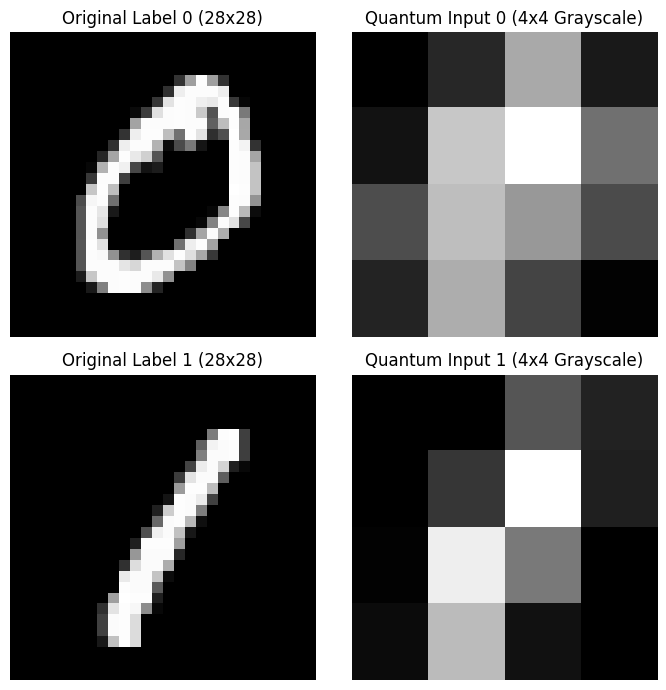

In [3]:
# Visualization
idx_0 = (raw_dataset.targets == 0).nonzero(as_tuple=True)[0][0]
idx_1 = (raw_dataset.targets == 1).nonzero(as_tuple=True)[0][0]

# Extraemos las imágenes originales (PIL Images 28x28)
img_0_raw, _ = raw_dataset[idx_0]
img_1_raw, _ = raw_dataset[idx_1]

# Extraemos las versiones transformadas para el modelo cuántico
img_0_transformed = transform(img_0_raw)
img_1_transformed = transform(img_1_raw)

# Revertimos el flattening y el escalado para poder dibujarlas en 4x4
img_0_view = (img_0_transformed / np.pi).view(4, 4).numpy()
img_1_view = (img_1_transformed / np.pi).view(4, 4).numpy()

# === PLOT: MATRIZ 2x2 ===
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

# Fila 1: El Número 0
axes[0, 0].imshow(img_0_raw, cmap='gray')
axes[0, 0].set_title("Original Label 0 (28x28)")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_0_view, cmap='gray')
axes[0, 1].set_title("Quantum Input 0 (4x4 Grayscale)")
axes[0, 1].axis('off')

# Fila 2: El Número 1
axes[1, 0].imshow(img_1_raw, cmap='gray')
axes[1, 0].set_title("Original Label 1 (28x28)")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_1_view, cmap='gray')
axes[1, 1].set_title("Quantum Input 1 (4x4 Grayscale)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Download and load MNIST training dataset (Only 0s and 1s)
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_idx = (full_train.targets == 0) | (full_train.targets == 1)
full_train.data, full_train.targets = full_train.data[train_idx], full_train.targets[train_idx]

# Load and filter Test Data (Only 0s and 1s)
full_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_idx = (full_test.targets == 0) | (full_test.targets == 1)
full_test.data, full_test.targets = full_test.data[test_idx], full_test.targets[test_idx]

# Use subsets for local simulation speed (e.g., 200 train, 100 test)
train_subset = torch.utils.data.Subset(full_train, torch.randperm(len(full_train))[:200])
test_subset = torch.utils.data.Subset(full_test, torch.randperm(len(full_test))[:100])

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=16, shuffle=False)


# Model Definition

In [5]:
# Quantum Circuit Tree Tensor Network

n_qubits = 16 # 4x4 image = 16 pixels
dev = qml.device("default.qubit", wires=n_qubits)

# Define TTN block: 4 Rotations and 1 Entanglement
def ttn_block(weights, wire1, wire2):
    qml.RY(weights[0], wires=wire1)
    qml.RY(weights[1], wires=wire2)
    qml.CNOT(wires=[wire1, wire2])
    qml.RX(weights[2], wires=wire1)
    qml.RX(weights[3], wires=wire2)

@qml.qnode(dev, interface="torch")
def qnode_ttn(inputs, weights):
    # Feature Map: 1 pixel per qubit
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    
    weight_idx = 0
    
    # Ansatz: Tree Tensor Network (Hierarchical reduction)
    
    # Layer 1: 16 qubits -> 8 blocks
    for i in range(0, 16, 2):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+1)
        weight_idx += 4
        
    # Layer 2: 8 active qubits -> 4 blocks
    for i in range(1, 16, 4):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+2)
        weight_idx += 4
        
    # Layer 3: 4 active qubits -> 2 blocks
    for i in range(3, 16, 8):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+4)
        weight_idx += 4
        
    # Layer 4: 2 active qubits -> 1 block (Final reduction)
    ttn_block(weights[weight_idx:weight_idx+4], 7, 15)
    
    # Measurement in Z of last qubit
    return qml.expval(qml.PauliZ(15))


In [6]:
# Pytorch Model
class QuantumTTN(nn.Module):
    def __init__(self):
        super(QuantumTTN, self).__init__()
        
        # A 16-qubit TTN has 15 blocks (8+4+2+1). 
        # Each block uses 4 weights. Total = 60 parameters.
        weight_shapes = {"weights": (60,)}
        
        self.qlayer = qml.qnn.TorchLayer(qnode_ttn, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        # Map[-1, 1] expectation value to [0, 1] probability
        prob = ((out + 1.0) / 2.0).view(-1, 1) 
        return prob

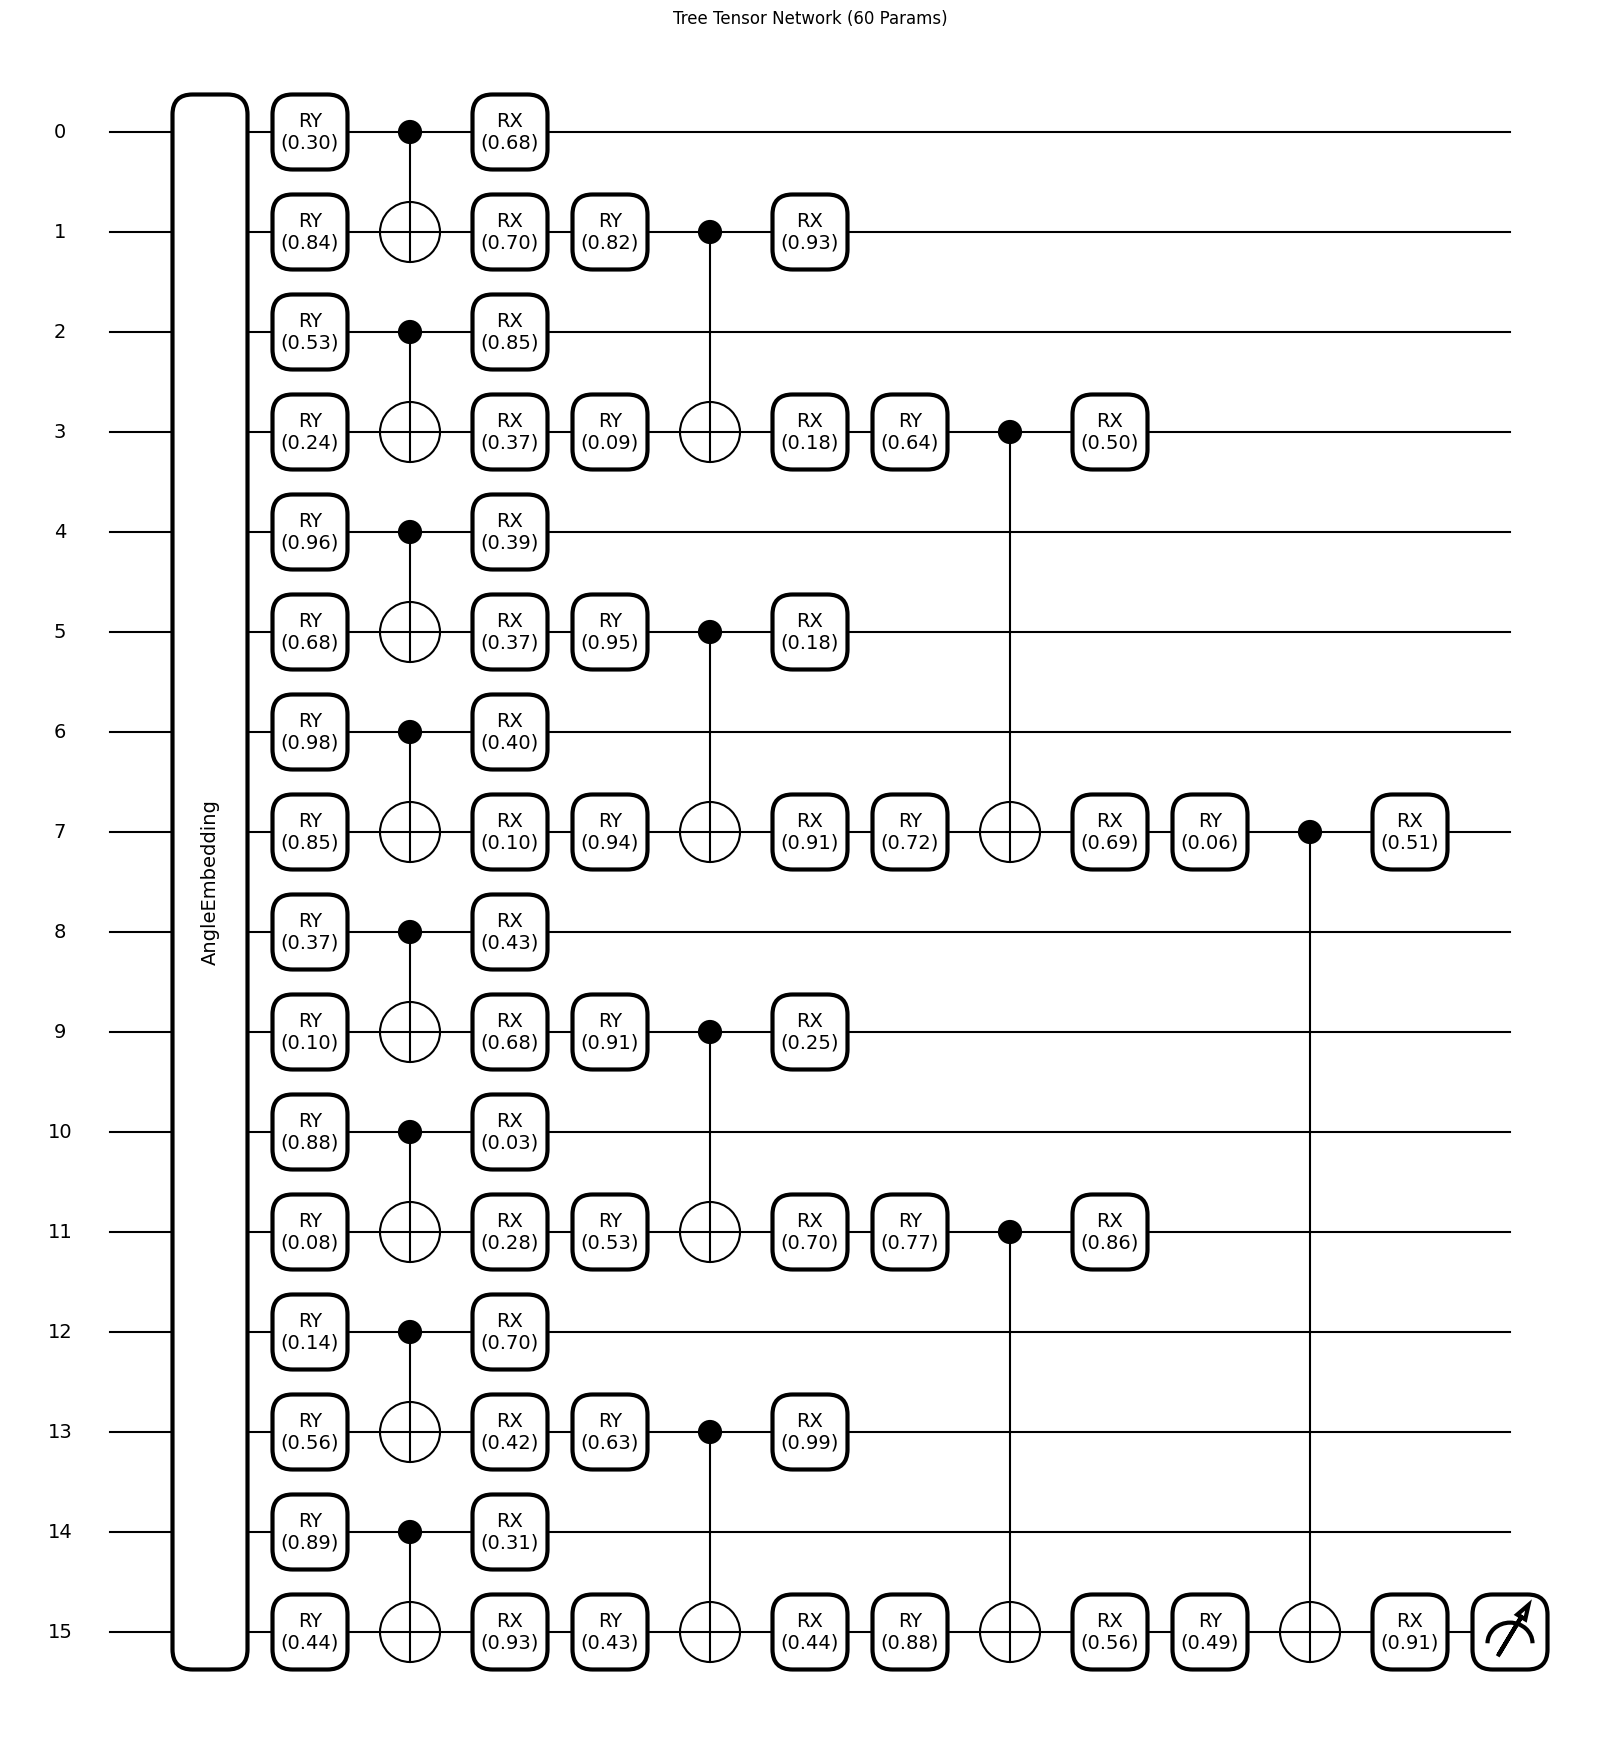

In [7]:
fig, ax = qml.draw_mpl(qnode_ttn, decimals=2)(torch.rand(16), torch.rand(60))
plt.title("Tree Tensor Network (60 Params)")
plt.show()

In [8]:
class ClassicalNN(nn.Module):
    def __init__(self):
        super(ClassicalNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 2), # 16 inputs -> 2 hidden neurons
            nn.ReLU(),
            nn.Linear(2, 1),  # 2 hidden -> 1 output
            nn.Sigmoid()      # Probability[0, 1]
        )

    def forward(self, x):
        return self.net(x)

In [9]:
model_quantum = QuantumTTN()
model_classical = ClassicalNN()

# Training Loop

In [10]:
# Training Loop
criterion = nn.BCELoss()

optimizer_quantum   = optim.Adam(model_quantum.parameters(),   lr=0.01)
optimizer_classical = optim.Adam(model_classical.parameters(), lr=0.01)

n_epochs = 15

history = {
    "quantum_train_loss":  [], "quantum_train_acc":  [],
    "quantum_test_loss":   [], "quantum_test_acc":   [],
    "classical_train_loss":[], "classical_train_acc":[],
    "classical_test_loss": [], "classical_test_acc": [],
}

def run_epoch(model, optimizer, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            y_batch = y_batch.float().view(-1, 1)  # BCELoss espera float [B,1]

            if train:
                optimizer.zero_grad()

            preds = model(X_batch)
            loss  = criterion(preds, y_batch)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            predicted   = (preds >= 0.5).float()
            correct    += (predicted == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


print(f"{'Epoch':>5} | {'Q-TrLoss':>9} {'Q-TrAcc':>8} {'Q-TeLoss':>9} {'Q-TeAcc':>8} "
      f"| {'C-TrLoss':>9} {'C-TrAcc':>8} {'C-TeLoss':>9} {'C-TeAcc':>8}")
print("-" * 95)

for epoch in range(1, n_epochs + 1):

    # Quantum
    q_tr_loss, q_tr_acc = run_epoch(model_quantum,   optimizer_quantum,   train_loader, train=True)
    q_te_loss, q_te_acc = run_epoch(model_quantum,   optimizer_quantum,   test_loader,  train=False)

    # Classical
    c_tr_loss, c_tr_acc = run_epoch(model_classical, optimizer_classical, train_loader, train=True)
    c_te_loss, c_te_acc = run_epoch(model_classical, optimizer_classical, test_loader,  train=False)

    # Save history
    history["quantum_train_loss"].append(q_tr_loss)
    history["quantum_train_acc"].append(q_tr_acc)
    history["quantum_test_loss"].append(q_te_loss)
    history["quantum_test_acc"].append(q_te_acc)
    history["classical_train_loss"].append(c_tr_loss)
    history["classical_train_acc"].append(c_tr_acc)
    history["classical_test_loss"].append(c_te_loss)
    history["classical_test_acc"].append(c_te_acc)

    print(f"{epoch:>5} | {q_tr_loss:>9.4f} {q_tr_acc:>8.3f} {q_te_loss:>9.4f} {q_te_acc:>8.3f} "
          f"| {c_tr_loss:>9.4f} {c_tr_acc:>8.3f} {c_te_loss:>9.4f} {c_te_acc:>8.3f}")

print("\nTraining Finished")

Epoch |  Q-TrLoss  Q-TrAcc  Q-TeLoss  Q-TeAcc |  C-TrLoss  C-TrAcc  C-TeLoss  C-TeAcc
-----------------------------------------------------------------------------------------------
    1 |    0.6666    0.595    0.6567    0.570 |    0.6163    0.605    0.5714    0.970
    2 |    0.6369    0.595    0.6306    0.570 |    0.5416    0.955    0.4883    0.980
    3 |    0.6036    0.595    0.6106    0.570 |    0.4604    0.940    0.3989    0.980
    4 |    0.5844    0.595    0.5931    0.570 |    0.3767    0.945    0.3142    0.980
    5 |    0.5564    0.595    0.5741    0.570 |    0.3041    0.945    0.2454    0.980
    6 |    0.5380    0.595    0.5596    0.570 |    0.2486    0.945    0.1937    0.980
    7 |    0.5225    0.595    0.5475    0.570 |    0.2086    0.945    0.1584    0.980
    8 |    0.5108    0.600    0.5334    0.590 |    0.1772    0.950    0.1313    0.980
    9 |    0.4985    0.600    0.5235    0.610 |    0.1566    0.950    0.1121    0.980
   10 |    0.4896    0.620    0.5118    0.61

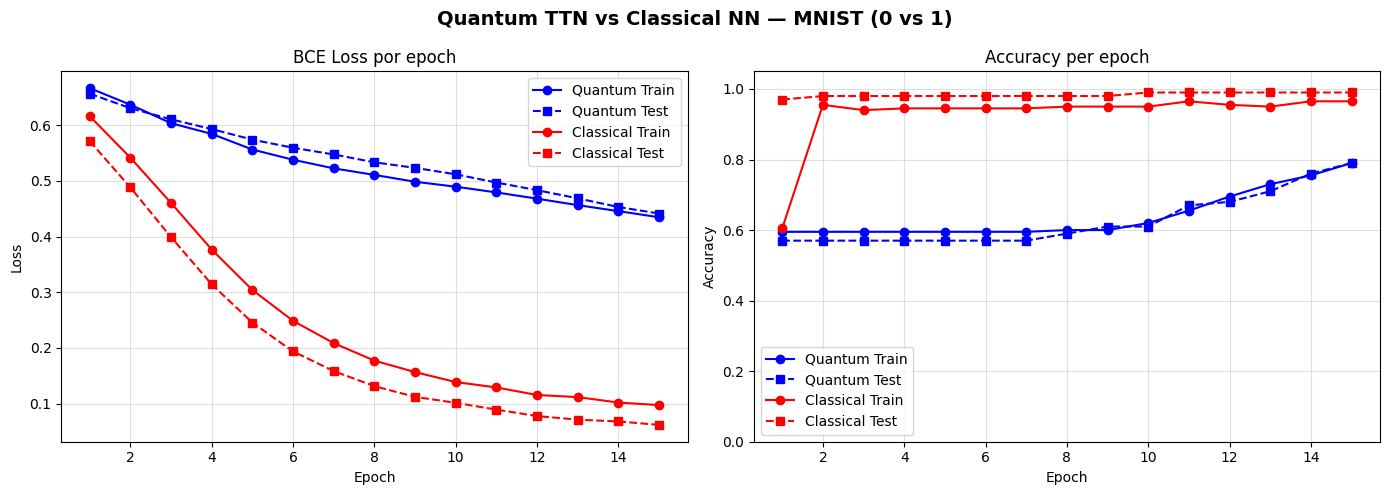

In [11]:
# Visualization
epochs_range = range(1, n_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(epochs_range, history["quantum_train_loss"],   "b-o",  label="Quantum Train")
axes[0].plot(epochs_range, history["quantum_test_loss"],    "b--s", label="Quantum Test")
axes[0].plot(epochs_range, history["classical_train_loss"], "r-o",  label="Classical Train")
axes[0].plot(epochs_range, history["classical_test_loss"],  "r--s", label="Classical Test")
axes[0].set_title("BCE Loss por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# --- Accuracy ---
axes[1].plot(epochs_range, history["quantum_train_acc"],   "b-o",  label="Quantum Train")
axes[1].plot(epochs_range, history["quantum_test_acc"],    "b--s", label="Quantum Test")
axes[1].plot(epochs_range, history["classical_train_acc"], "r-o",  label="Classical Train")
axes[1].plot(epochs_range, history["classical_test_acc"],  "r--s", label="Classical Test")
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle("Quantum TTN vs Classical NN — MNIST (0 vs 1)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Here we can see that the Quantum Model reached to a Barren Plateau in the middle of the training and the accuracy was not better than the classical model

# Data Re-uploading TTN

From https://arxiv.org/abs/1907.02085 paper, it seems that re-uploading the data improves the ability of the classifiers to describe complex data

Let's prove it

In [12]:
# Data Re-Uploading TTN

n_qubits = 16
dev_reup = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_reup, interface="torch")
def qnode_ttn_reup(inputs, weights):
    weight_idx = 0

    # Layer 1: Re-upload + 8 blocks
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    for i in range(0, 16, 2):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+1)
        weight_idx += 4
    # 8 blocks × 4 = 32 weights

    # Layer 2: Re-upload + 4 blocks
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    for i in range(1, 16, 4):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+2)
        weight_idx += 4
    # 4 blocks × 4 = 16 weights

    # Layer 3: Re-upload + 2 blocks
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    for i in range(3, 16, 8):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+4)
        weight_idx += 4
    # 2 blocks × 4 = 8 weights

    # Layer 4: Re-upload + 1 final block
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    ttn_block(weights[weight_idx:weight_idx+4], 7, 15)
    weight_idx += 4
    # 1 bloque × 4 = 4 weights

    # Total: (8+4+2+1) blocks × 4 weights = 60 weights
    return qml.expval(qml.PauliZ(15))

In [13]:
class QuantumTTN_ReUp(nn.Module):
    def __init__(self):
        super(QuantumTTN_ReUp, self).__init__()
        weight_shapes = {"weights": (60,)}
        self.qlayer = qml.qnn.TorchLayer(qnode_ttn_reup, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        prob = ((out + 1.0) / 2.0).view(-1, 1)
        return prob

In [14]:
model_reup = QuantumTTN_ReUp()
optimizer_reup = optim.Adam(model_reup.parameters(), lr=0.01)

history_reup = {
    "train_loss": [], "train_acc": [],
    "test_loss":  [], "test_acc":  [],
}

print(f"{'Epoch':>5} | {'TrLoss':>9} {'TrAcc':>8} {'TeLoss':>9} {'TeAcc':>8}")
print("-" * 50)

for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc = run_epoch(model_reup, optimizer_reup, train_loader, train=True)
    te_loss, te_acc = run_epoch(model_reup, optimizer_reup, test_loader,  train=False)

    history_reup["train_loss"].append(tr_loss)
    history_reup["train_acc"].append(tr_acc)
    history_reup["test_loss"].append(te_loss)
    history_reup["test_acc"].append(te_acc)

    print(f"{epoch:>5} | {tr_loss:>9.4f} {tr_acc:>8.3f} {te_loss:>9.4f} {te_acc:>8.3f}")

print("\nTraining Completed")

Epoch |    TrLoss    TrAcc    TeLoss    TeAcc
--------------------------------------------------
    1 |    0.6360    0.595    0.6246    0.570
    2 |    0.6004    0.595    0.5939    0.570
    3 |    0.5722    0.600    0.5591    0.580
    4 |    0.5305    0.640    0.5193    0.650
    5 |    0.4914    0.680    0.4844    0.720
    6 |    0.4600    0.755    0.4583    0.720
    7 |    0.4343    0.795    0.4371    0.780
    8 |    0.4191    0.815    0.4234    0.800
    9 |    0.4059    0.840    0.4130    0.830
   10 |    0.3963    0.860    0.4018    0.860
   11 |    0.3878    0.865    0.3933    0.860
   12 |    0.3800    0.870    0.3823    0.860
   13 |    0.3723    0.880    0.3754    0.880
   14 |    0.3656    0.885    0.3666    0.880
   15 |    0.3587    0.885    0.3619    0.880

Training Completed


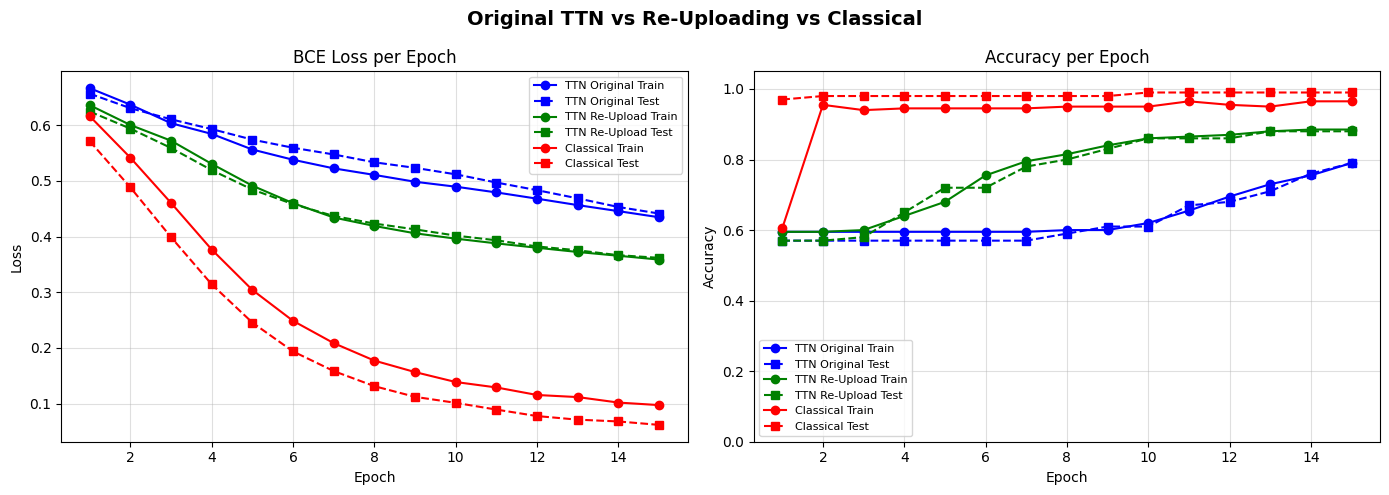

In [15]:
epochs_range = range(1, n_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = [
    (history["quantum_train_loss"], history["quantum_test_loss"],
     history["quantum_train_acc"],  history["quantum_test_acc"],  "b", "TTN Original"),
    (history_reup["train_loss"],    history_reup["test_loss"],
     history_reup["train_acc"],     history_reup["test_acc"],     "g", "TTN Re-Upload"),
    (history["classical_train_loss"],  history["classical_test_loss"],
     history["classical_train_acc"],   history["classical_test_acc"],   "r", "Classical"),
]

for tr_loss, te_loss, tr_acc, te_acc, color, label in modelos:
    axes[0].plot(epochs_range, tr_loss, f"{color}-o",  label=f"{label} Train")
    axes[0].plot(epochs_range, te_loss, f"{color}--s", label=f"{label} Test")
    axes[1].plot(epochs_range, tr_acc,  f"{color}-o",  label=f"{label} Train")
    axes[1].plot(epochs_range, te_acc,  f"{color}--s", label=f"{label} Test")

axes[0].set_title("BCE Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.4)

plt.suptitle("Original TTN vs Re-Uploading vs Classical", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Here we can see that Re-uploading the data really improves the model Accuracy